Shape: (7043, 20)

Churn Distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64


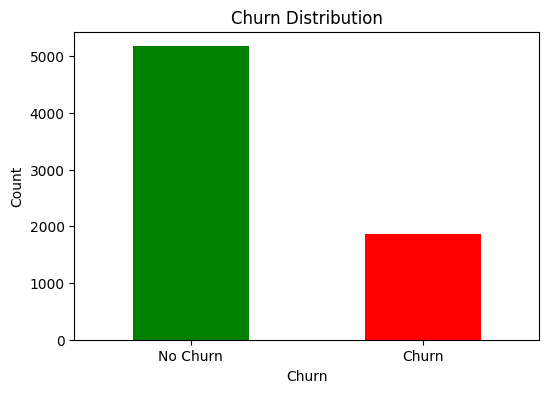

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
df = pd.read_csv('../data/Churn Prediction Dataset.csv')

# Clean Data
df = df.drop('customerID', axis=1)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

print("Shape:", df.shape)
print("\nChurn Distribution:")
print(df['Churn'].value_counts())

# Plot Churn Distribution
plt.figure(figsize=(6,4))
df['Churn'].value_counts().plot(kind='bar', color=['green','red'])
plt.title('Churn Distribution')
plt.xticks([0,1], ['No Churn','Churn'], rotation=0)
plt.ylabel('Count')
plt.show()

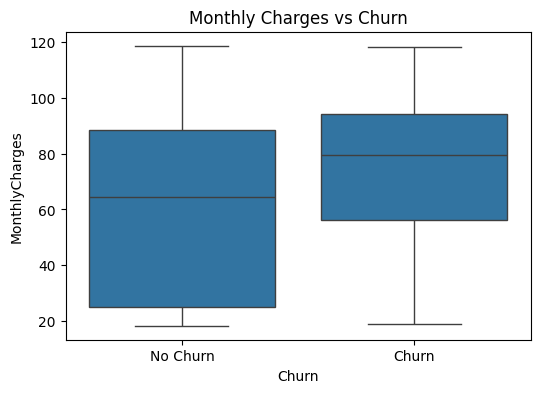

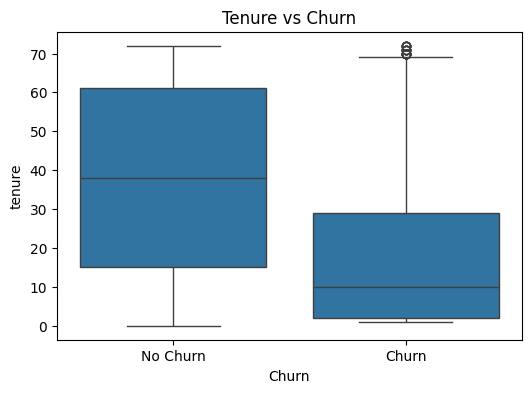

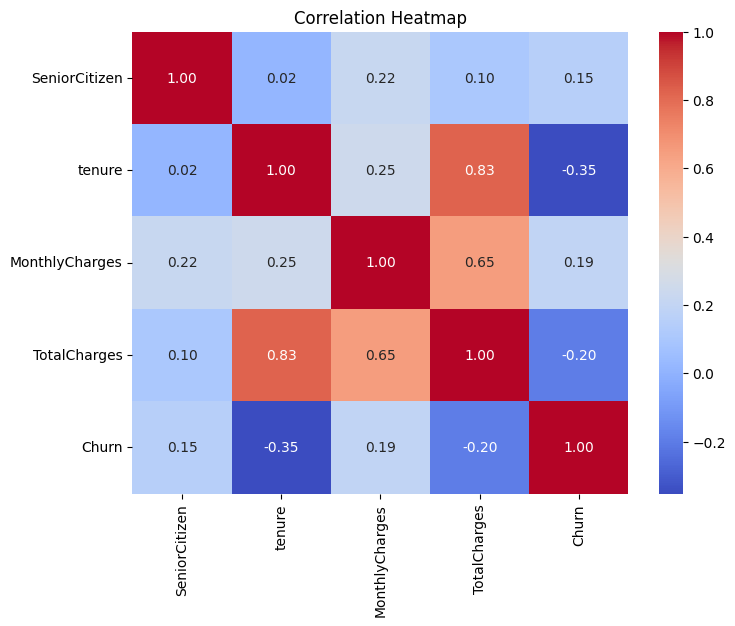

In [2]:
# Monthly Charges vs Churn
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title('Monthly Charges vs Churn')
plt.xticks([0,1], ['No Churn','Churn'])
plt.show()

# Tenure vs Churn
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title('Tenure vs Churn')
plt.xticks([0,1], ['No Churn','Churn'])
plt.show()

# Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.select_dtypes(include='number').corr(), 
            annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Encode categorical variables
le = LabelEncoder()––
cat_cols = df.select_dtypes(include=['object', 'str']).columns.tolist()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# Features and target
X = df.drop(['Churn'], axis=1)
y = df['Churn']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
print("Train size:", X_train.shape, "| Test size:", X_test.shape)

Train size: (5634, 19) | Test size: (1409, 19)


=== Logistic Regression ===
Accuracy: 0.815471965933286
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.68      0.58      0.62       373

    accuracy                           0.82      1409
   macro avg       0.77      0.74      0.75      1409
weighted avg       0.81      0.82      0.81      1409



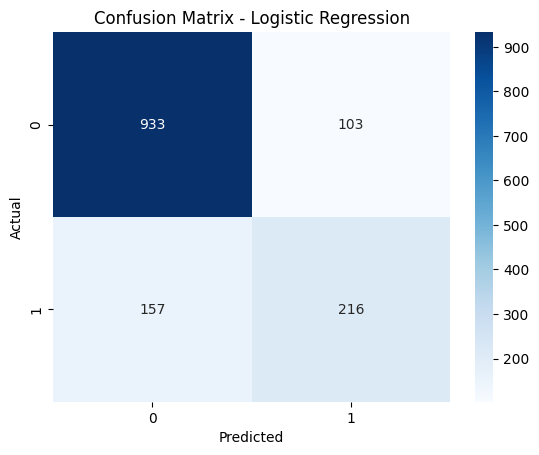

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.show()

====== SVM Results ======
Accuracy  : 0.8070
Precision : 0.6850
Recall    : 0.5013
F1-Score  : 0.5789


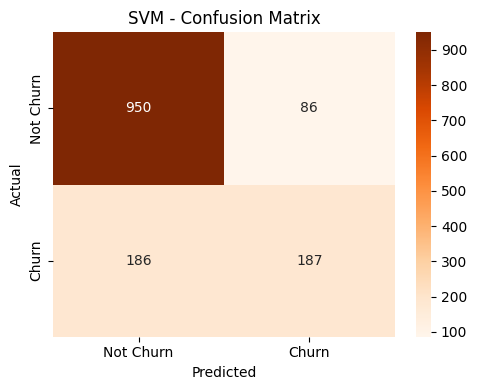

Confusion matrix saved to outputs folder.


In [5]:
# ============================================================
# STAGE: SVM (Support Vector Machine)
# ============================================================

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# --- Train SVM ---
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_model.fit(X_train, y_train)

# --- Predict ---
y_pred_svm = svm_model.predict(X_test)

# --- Evaluation Metrics ---
svm_accuracy  = accuracy_score(y_test, y_pred_svm)
svm_precision = precision_score(y_test, y_pred_svm)
svm_recall    = recall_score(y_test, y_pred_svm)
svm_f1        = f1_score(y_test, y_pred_svm)

print("====== SVM Results ======")
print(f"Accuracy  : {svm_accuracy:.4f}")
print(f"Precision : {svm_precision:.4f}")
print(f"Recall    : {svm_recall:.4f}")
print(f"F1-Score  : {svm_f1:.4f}")

# --- Confusion Matrix ---
cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Not Churn', 'Churn'],
            yticklabels=['Not Churn', 'Churn'])
plt.title('SVM - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('../outputs/svm_confusion_matrix.png', dpi=150)
plt.show()
print("Confusion matrix saved to outputs folder.")

In [6]:
# Decision Tree Model
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

print("====== Decision Tree Results ======")
print("Accuracy :", accuracy_score(y_test, dt_pred).round(4))
print("Precision:", precision_score(y_test, dt_pred).round(4))
print("Recall   :", recall_score(y_test, dt_pred).round(4))
print("F1-Score :", f1_score(y_test, dt_pred).round(4))

cm = confusion_matrix(y_test, dt_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Not Churn','Churn'],
            yticklabels=['Not Churn','Churn'])
plt.title('Decision Tree - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

====== Decision Tree Results ======


AttributeError: 'float' object has no attribute 'round'

====== Decision Tree Results ======
Accuracy : 0.7246
Precision: 0.4809
Recall   : 0.5067
F1-Score : 0.4935


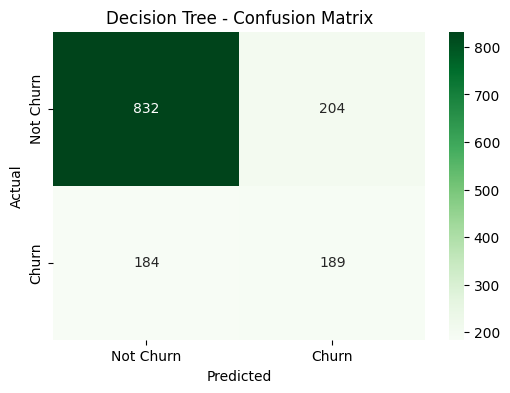

In [7]:
# Decision Tree Model
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_score, recall_score, f1_score

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

print("====== Decision Tree Results ======")
print("Accuracy :", round(accuracy_score(y_test, dt_pred), 4))
print("Precision:", round(precision_score(y_test, dt_pred), 4))
print("Recall   :", round(recall_score(y_test, dt_pred), 4))
print("F1-Score :", round(f1_score(y_test, dt_pred), 4))

cm = confusion_matrix(y_test, dt_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Not Churn','Churn'],
            yticklabels=['Not Churn','Churn'])
plt.title('Decision Tree - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

====== Random Forest Results ======
Accuracy : 0.797
Precision: 0.6617
Recall   : 0.4772
F1-Score : 0.5545


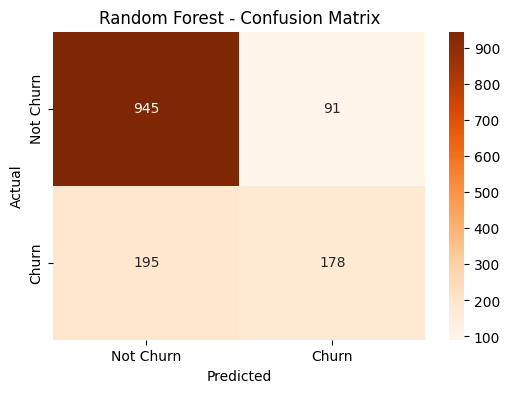

In [8]:
# Random Forest Model
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("====== Random Forest Results ======")
print("Accuracy :", round(accuracy_score(y_test, rf_pred), 4))
print("Precision:", round(precision_score(y_test, rf_pred), 4))
print("Recall   :", round(recall_score(y_test, rf_pred), 4))
print("F1-Score :", round(f1_score(y_test, rf_pred), 4))

cm = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Not Churn','Churn'],
            yticklabels=['Not Churn','Churn'])
plt.title('Random Forest - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()